In [81]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer, LabelEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import joblib

In [82]:
# importing the dataframe
df = pd.read_csv(r"C:\Users\hi\Desktop\Project 4.2\student_dropout_dataset.csv")
df.head()

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass,label_name
0,STU00001,26,Alexandria,2024-01-13,0,3,5,0.3571,5.29,10,5,0.1064,0,0,active
1,STU00002,23,Amman,2024-05-05,0,6,0,0.0000,0.84,7,0,0.6627,1,2,dropped
2,STU00003,17,Dubai,2024-03-12,0,3,1,0.0435,1.79,36,0,0.7299,1,2,dropped
3,STU00004,23,Alexandria,2024-12-12,0,6,13,0.4396,0.78,9,0,0.5315,1,1,at-risk
4,STU00005,20,Baghdad,2024-02-14,0,5,5,0.2078,0.92,11,0,0.7904,1,2,dropped


In [83]:
# checking for null values
df.isna().sum()

student_id                0
age                       0
region                    0
enroll_date               0
exam_season               0
courses_enrolled          0
completed_assignments     0
completion_rate           0
login_frequency           0
last_activity_days_ago    0
forum_posts_count         0
dropout_score             0
label                     0
label_multiclass          0
label_name                0
dtype: int64

In [84]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

In [85]:
df.columns

Index(['student_id', 'age', 'region', 'enroll_date', 'exam_season',
       'courses_enrolled', 'completed_assignments', 'completion_rate',
       'login_frequency', 'last_activity_days_ago', 'forum_posts_count',
       'dropout_score', 'label', 'label_multiclass', 'label_name'],
      dtype='object')

In [86]:
X = df.drop(columns=['student_id','enroll_date','dropout_score','label','label_multiclass', 'label_name'])
y = df['label_multiclass']

In [87]:
le = LabelEncoder()
X['region'] = le.fit_transform(X['region'])

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.2)

In [89]:
skewed_col = ['age', 'completed_assignments', 'completion_rate', 'login_frequency', 'last_activity_days_ago','forum_posts_count']

In [90]:
preprocessing = ColumnTransformer(
    transformers=[
        ('scaler',StandardScaler(), X.columns),
        ('handling_skew',PowerTransformer(),skewed_col)
    ]
)

In [91]:
model = XGBClassifier(n_estimators=10,max_depth=10,random_state=42)


In [92]:
model_pipeline = Pipeline(
    steps=[
        ('preprocessing',preprocessing),
        ('classifier',model)
    ]
)

In [93]:
model_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  Index(['age', 'region', 'exam_season', 'courses_enrolled',
       'completed_assignments', 'completion_rate', 'login_frequency',
       'last_activity_days_ago', 'forum_posts_count'],
      dtype='object')),
                                                 ('handling_skew',
                                                  PowerTransformer(),
                                                  ['age',
                                                   'completed_assignments',
                                                   'completion_r...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=10, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=10, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [94]:

y_pred = model_pipeline.predict(X_test)

In [95]:
#model evaluation
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87       333
           1       0.77      0.74      0.75       327
           2       0.87      0.92      0.89       340

    accuracy                           0.84      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.84      0.84      0.84      1000



# Hyperparameter tuning

In [96]:
XGBClassifier()
params = {
    'classifier__n_estimators':[10,20,40,60],
    'classifier__max_depth':[5,10,15,20,25],
    'classifier__learning_rate':[0.01,0.05,0.1,0.2],
    # 3. Regularization
    'classifier__gamma': [0, 0.1, 0.2, 0.5, 1, 5],
    'classifier__reg_alpha': [0, 0.01, 0.1, 1, 10],
    'classifier__reg_lambda': [0.01, 0.1, 1, 10],
}

In [97]:
from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator = model_pipeline,
    param_distributions = params,
    n_jobs = -1,
    cv = 5
)

In [98]:
random_search.fit(X_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('scaler',
                                                                               StandardScaler(),
                                                                               Index(['age', 'region', 'exam_season', 'courses_enrolled',
       'completed_assignments', 'completion_rate', 'login_frequency',
       'last_activity_days_ago', 'forum_posts_count'],
      dtype='object')),
                                                                              ('handling_skew',
                                                                               PowerTransformer(),
                                                                               ['age',
                                                                                'co...
                                                            multi_strategy=None,
                                                            n_estimators=10,
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_jobs=-1,
                   param_distributions={'classifier__gamma': [0, 0.1, 0.2, 0.5,
                                                              1, 5],
                                        'classifier__learning_rate': [0.01,
                                                                      0.05, 0.1,
                                                                      0.2],
                                        'classifier__max_depth': [5, 10, 15, 20,
                                                                  25],
                                        'classifier__n_estimators': [10, 20, 40,
                                                                     60],
                                        'classifier__reg_alpha': [0, 0.01, 0.1,
                                                                  1, 10],
                                        'classifier__reg_lambda': [0.01, 0.1, 1,
                                                                   10]})

In [103]:
tuned_model = random_search.best_estimator_

In [104]:
tuned_y_pred = tuned_model.predict(X_test)

In [105]:
print(classification_report(y_test, tuned_y_pred))

              precision    recall  f1-score   support

           0       0.91      0.83      0.87       333
           1       0.75      0.78      0.77       327
           2       0.87      0.92      0.90       340

    accuracy                           0.84      1000
   macro avg       0.85      0.84      0.84      1000
weighted avg       0.85      0.84      0.84      1000



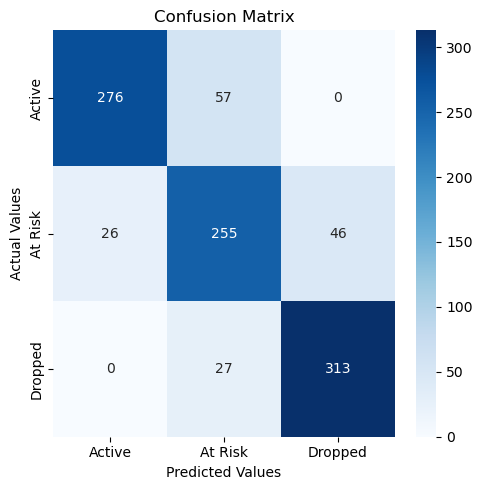

In [106]:
# plotting a confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, tuned_y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, cmap='Blues',fmt='d',
           xticklabels=['Active','At Risk','Dropped'],
           yticklabels=['Active','At Risk','Dropped'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.tight_layout()
plt.savefig('Confussion Matrix.png')
plt.show()

In [107]:
joblib.dump(tuned_model, 'xgb_dropout_model')

['xgb_dropout_model']